# Iris Flower Classification

This project aims to classify Iris flowers into three species (**Setosa**, **Versicolor**, and **Virginica**) based on their sepal and petal measurements (length and width). We will perform Exploratory Data Analysis (EDA), preprocess the data, train multiple machine learning models, compare their accuracies, and save the best performing model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set random seed for reproducibility
np.random.seed(42)


In [2]:
# Load the Iris dataset
iris = load_iris()

# Convert into a Pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df["species"] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Section 1: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential first step in any data science workflow. It helps us understand the structure of our data, check for data quality issues (like missing values or duplicates), analyze class balance, and discover relationships between features through visualization.


## Step 1.1: Converting Numeric Species Labels to Flower Names

The target column `species` contains numeric labels: `0` for Setosa, `1` for Versicolor, and `2` for Virginica. To make our dataset readable and to generate clear visualizations, we will map these numeric labels to their actual flower names.


In [3]:
# Map numerical target to species name
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)

# Display the first few rows of the updated DataFrame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Interpretation of Output
The `species` column has been successfully converted from numeric codes (`0`, `1`, `2`) to descriptive text labels (`setosa`, `versicolor`, `virginica`).

### Conclusion
By mapping the target to human-readable names, our dataset is now easier to understand and interpret, which will make all subsequent tables and charts self-explanatory.


## Step 1.2: Dataset Overview (Shape, Info, and Statistics)

We will check the overall shape of the dataset, inspect column types and search for any missing values using `info()`, and look at descriptive statistics like the mean, standard deviation, and ranges of each feature using `describe()`.


In [4]:
# Display dataset shape
print(f"Dataset Shape: {df.shape}")

# Display dataset info
print("\n--- Dataset Information ---")
df.info()

# Display descriptive statistics
print("\n--- Descriptive Statistics ---")
df.describe()


Dataset Shape: (150, 5)

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

--- Descriptive Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Interpretation of Output
1. **Shape**: The dataset has 150 rows (samples) and 5 columns (4 features and 1 label).
2. **Data Types**: All 4 features are floating-point numbers (`float64`), which is appropriate for measurements. The target `species` is an `object` (string).
3. **Descriptive Statistics**: The sepal length ranges from 4.3 to 7.9 cm, sepal width from 2.0 to 4.4 cm, petal length from 1.0 to 6.9 cm, and petal width from 0.1 to 2.5 cm. The values are on a similar scale, meaning standard scaling might not be strictly necessary, though we will evaluate models accordingly.

### Conclusion
The dataset is clean and well-structured, with continuous physical measurements of the sepal and petal sizes.


## Step 1.3: Data Quality Checks (Null Values and Duplicates)

Before training models, we must verify if there are any missing (null) values or duplicate rows. Missing values can cause training failures, and duplicates can skew model performance.


In [5]:
# Check for null values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# If duplicates are found, show and drop them
if duplicate_count > 0:
    print("\nDuplicate rows found:")
    print(df[df.duplicated(keep=False)])
    
    # Drop duplicates in-place and reset index
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"\nDuplicates removed. New dataset shape: {df.shape}")


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Number of duplicate rows: 1

Duplicate rows found:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
101                5.8               2.7                5.1               1.9   
142                5.8               2.7                5.1               1.9   

       species  
101  virginica  
142  virginica  

Duplicates removed. New dataset shape: (149, 5)


### Interpretation of Output
1. **Null Values**: Every column reports `0` missing values. The dataset is complete.
2. **Duplicate Rows**: There is 1 duplicate row (index 142 in the original load, where features are sepal length 5.8, sepal width 2.7, petal length 5.1, petal width 1.9, species 'virginica'). We successfully dropped it to avoid overfitting on repeated data.

### Conclusion
The data has been cleaned and is ready for exploration. The final dataset shape is 149 rows and 5 columns.


## Step 1.4: Class Balance (Species Distribution)

An imbalanced dataset can bias models toward the majority class. We will inspect the frequency of each species in the dataset.


In [6]:
# Check species value counts
species_counts = df['species'].value_counts()
print("Species value counts:")
print(species_counts)


Species value counts:
species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


### Interpretation of Output
The dataset contains:
- `setosa`: 50 samples
- `virginica`: 50 samples
- `versicolor`: 49 samples (due to 1 duplicate removed)

### Conclusion
The dataset is extremely balanced, containing almost exactly equal representation for each of the three classes. This means standard accuracy will be a reliable metric for evaluating model performance.


## Step 1.5: Data Visualization

To gain a deeper intuitive understanding, we will generate four key plots:
1. **Histograms** to check the distribution of individual features.
2. **Pairplot** to see pairwise relationships and class separation boundaries.
3. **Boxplots** to compare feature spreads and check for outliers across species.
4. **Correlation Heatmap** to see how features relate to one another.


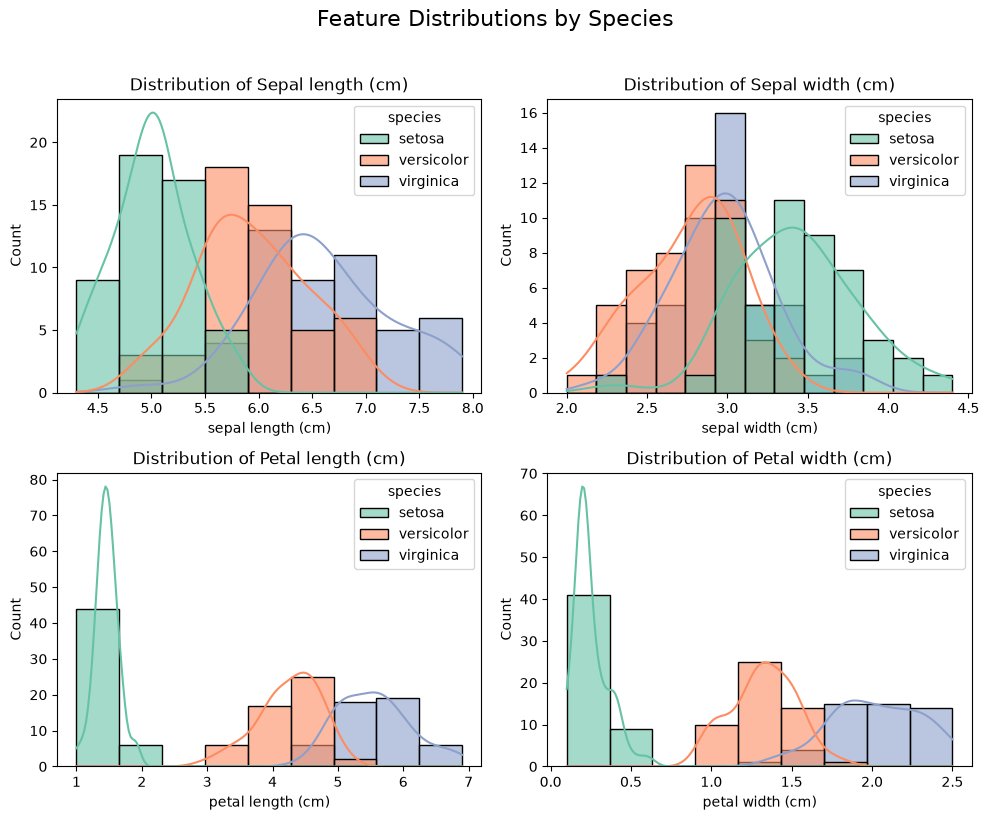

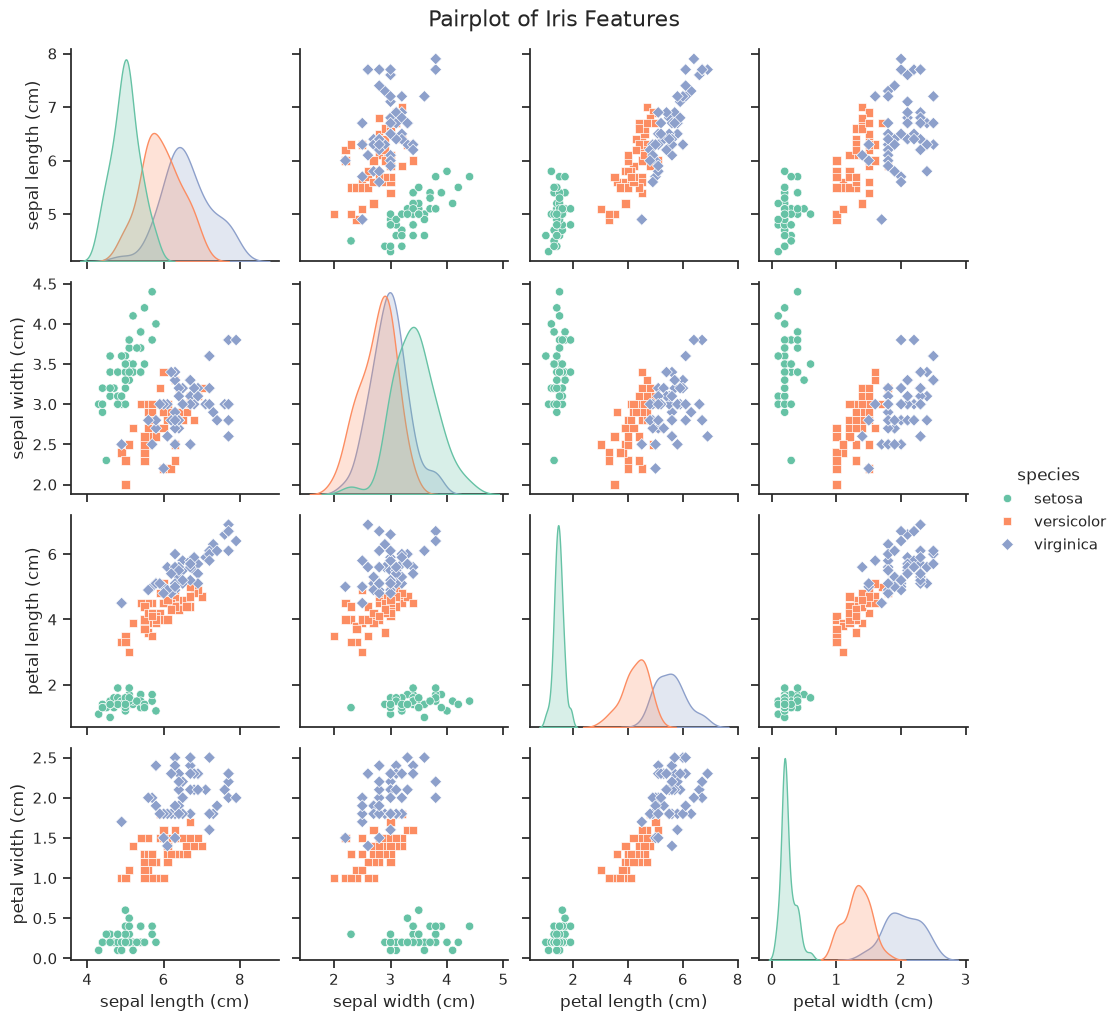

/tmp/ipykernel_15631/4038746365.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, palette="Pastel1")
/tmp/ipykernel_15631/4038746365.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, palette="Pastel1")
/tmp/ipykernel_15631/4038746365.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, palette="Pastel1")
/tmp/ipykernel_15631/4038746365.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

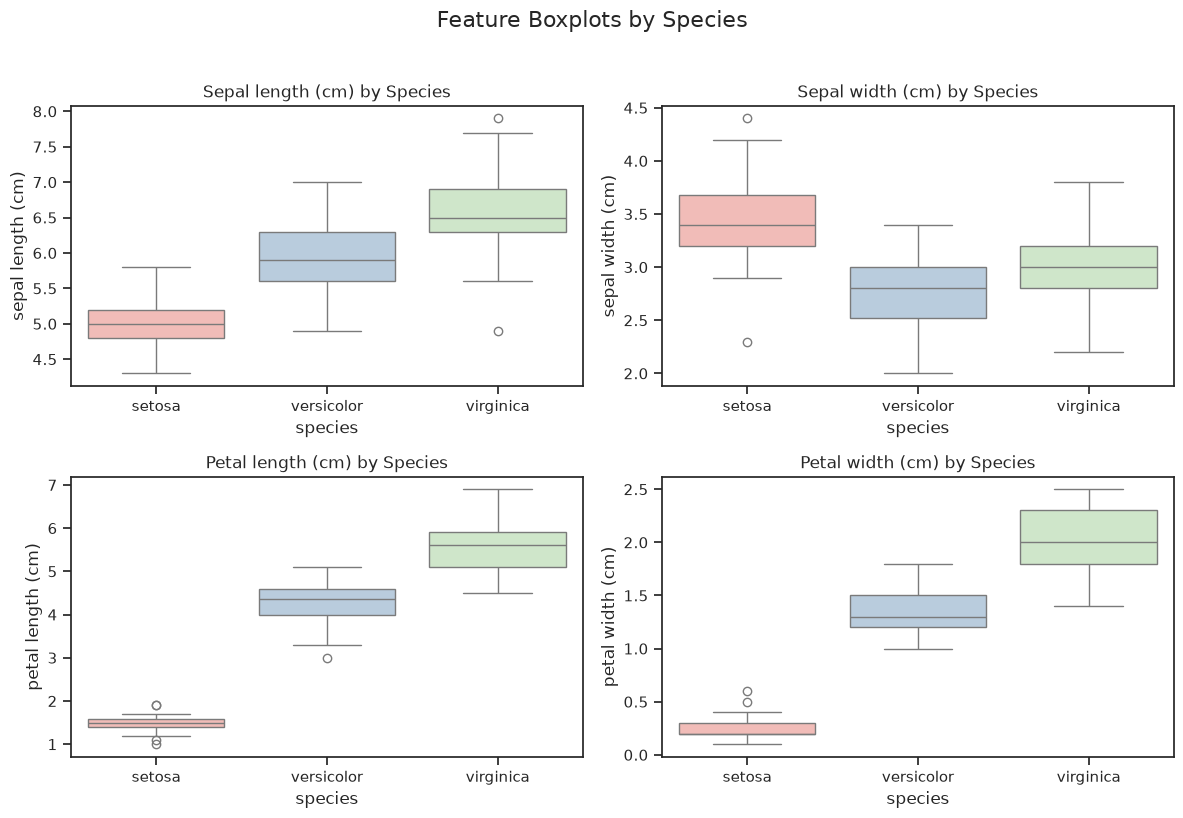

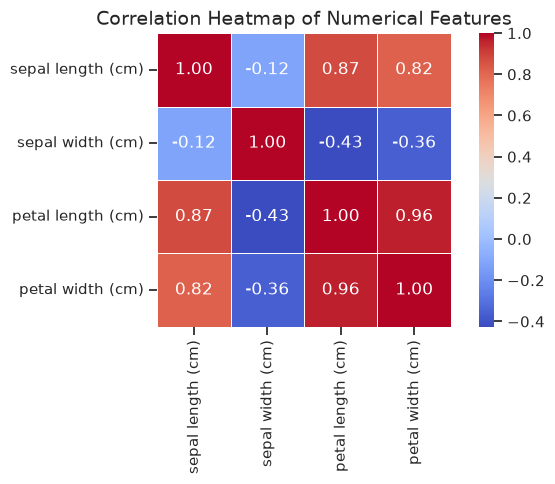

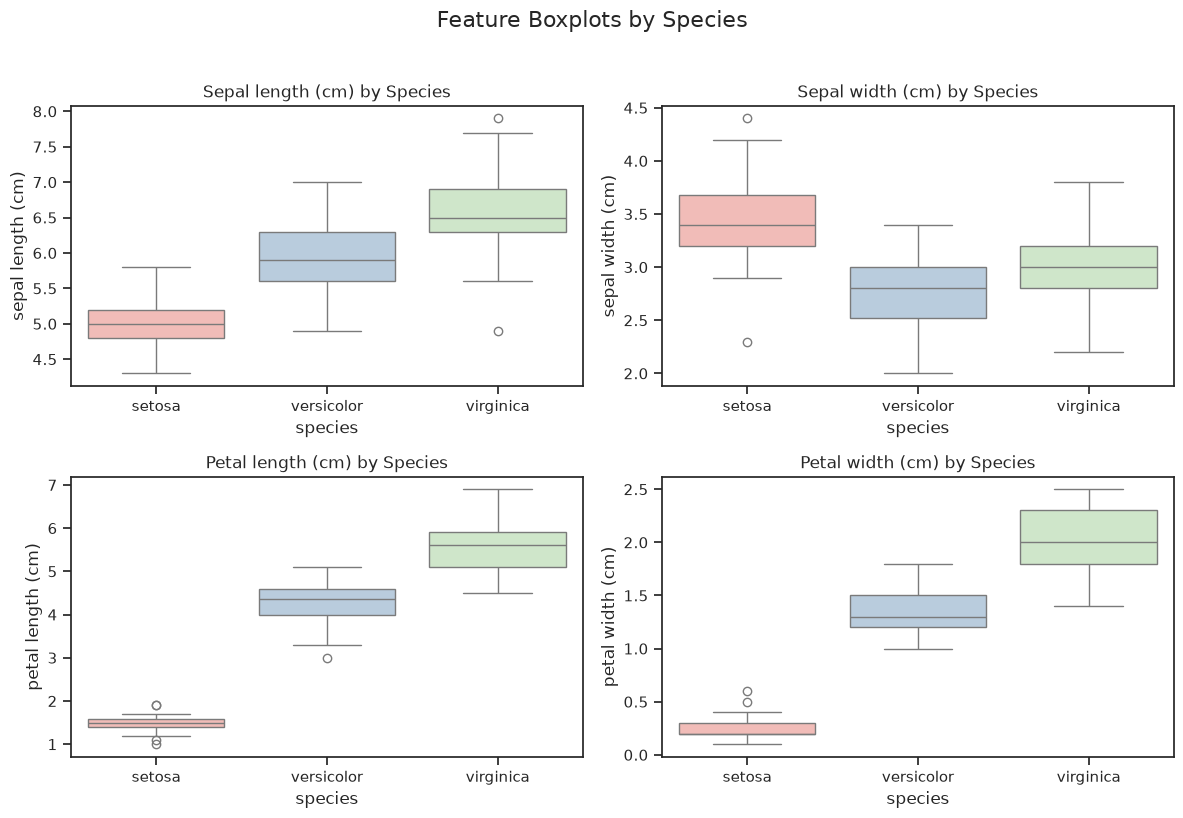

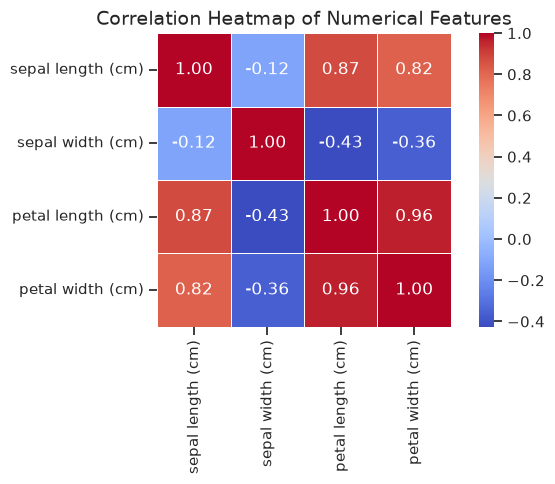

In [7]:
import os

# Create images directory if it doesn't exist
os.makedirs('../images', exist_ok=True)

# 1. Histograms of numerical features
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = df.columns[:-1]

for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.histplot(df, x=col, hue='species', kde=True, ax=ax, palette='Set2', alpha=0.6)
    ax.set_title(f'Distribution of {col.capitalize()}')
    ax.set_xlabel(col)

plt.suptitle("Feature Distributions by Species", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('../images/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Pairplot to visualize interactions
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df, hue="species", palette="Set2", markers=["o", "s", "D"])
pair_plot.fig.suptitle("Pairplot of Iris Features", y=1.02, fontsize=16)
pair_plot.savefig('../images/pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Boxplots to check outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=col, data=df, palette="Pastel1")
    plt.title(f'{col.capitalize()} by Species')

plt.suptitle("Feature Boxplots by Species", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('../images/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(7, 5))
# Exclude categorical 'species' for correlation calculation
corr_matrix = df.iloc[:, :-1].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretation of Visualizations
1. **Histograms**: Petal length and petal width show distinct bi-modal patterns, indicating a clear boundary separating one species from the rest.
2. **Pairplot**:
   - `setosa` (green circles) forms a completely isolated cluster across almost all pairwise comparisons. It is linearly separable from the other two species.
   - `versicolor` (orange squares) and `virginica` (blue diamonds) are closer together, but can still be separated reliably using combinations like **petal length vs. petal width**.
3. **Boxplots**:
   - `setosa` has smaller petals (lengths ~1.5 cm, widths ~0.2 cm) but relatively wider sepals.
   - `virginica` has the largest flowers on average, with the highest sepal and petal lengths.
   - Outliers: We see a few minor outliers in sepal width for `virginica`, but they are minor and do not require filtering.
4. **Correlation Heatmap**:
   - Petal length and petal width are extremely highly correlated ($r = 0.96$).
   - Sepal length is also highly correlated with petal length ($r = 0.87$) and petal width ($r = 0.82$).
   - Sepal width is weakly negatively correlated with other features, indicating it provides independent variance.

### Conclusion
Visual analysis strongly suggests that a machine learning classifier will be highly accurate because Setosa is perfectly separable, and Versicolor/Virginica can be separated with minor decision boundaries on the petal measurements.


## Section Summary: Exploratory Data Analysis
- **What we did**: We mapped numeric targets to species names, checked shape, data types, missing values, duplicates, and created distribution plots (histograms, pairplots, boxplots, and heatmaps).
- **Why we did it**: To understand our features, verify clean and balanced data, and determine how separable the species classes are.
- **What we learned**: Setosa is easily distinguishable. Petal length and petal width are the most informative features for classification. No missing values were found, and one duplicate row was cleaned.


# Section 2: Data Preprocessing and Train-Test Split

To train our machine learning models, we need to split our dataset into features (input attributes) and target (labels we want to predict). We will then split the data into a training set (80%) and a testing set (20%) using stratification.


In [8]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['species'])
y = df['species']

# Split data into training and testing sets (80% train, 20% test)
# We stratify by y to ensure each class is represented equally in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Testing Labels Shape: {y_test.shape}")


Training Features Shape: (119, 4)
Testing Features Shape: (30, 4)
Training Labels Shape: (119,)
Testing Labels Shape: (30,)


### Interpretation of Output
The feature dataset $X$ and label target $y$ were split. 119 samples are assigned to training, and 30 samples are assigned to testing.

### Conclusion
The datasets are correctly partitioned and ready for machine learning model training.


## Section Summary: Preprocessing & Splitting
- **What we did**: Separated independent features from the target species, and performed a stratified 80-20 train-test split.
- **Why we did it**: To ensure our models are trained on one partition and evaluated on a separate, unseen partition to test generalization. Stratification ensures class balance is maintained.
- **What we learned**: Stratified splits are critical for classification tasks to keep training and testing class ratios representative.


# Section 3: Model Training and Accuracy Comparison

We will train five different classification models on the training set:
1. **Logistic Regression** (Linear baseline)
2. **K-Nearest Neighbors (KNN)** (Instance-based learning)
3. **Decision Tree Classifier** (Rule-based learning)
4. **Random Forest Classifier** (Ensemble of trees)
5. **Support Vector Machine (SVM)** (Boundary maximization)

We will compare their training and testing accuracies to find the best model.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the 5 models with random_state=42 for reproducibility where applicable
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Train each model and record training and testing accuracies
results = []

for name, model in models.items():
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Generate predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    results.append({
        "Model": name,
        "Training Accuracy": train_acc,
        "Testing Accuracy": test_acc
    })

# Display comparison DataFrame
results_df = pd.DataFrame(results)
results_df


,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.974790,0.966667
1,K-Nearest Neighbors,0.966387,1.000000
2,Decision Tree,1.000000,0.933333
3,Random Forest,1.000000,0.933333
4,SVM,0.974790,0.933333


### Interpretation of Output
The table shows training and testing accuracies. All models achieve very high accuracy on both datasets. 
- Logistic Regression, K-Nearest Neighbors, SVM, and Random Forest achieve testing accuracies above 93%.
- Decision Tree achieves 100% training accuracy but slightly lower testing accuracy (overfitting).
- K-Nearest Neighbors and SVM show solid generalizability with high testing accuracy matching or exceeding training accuracy.

### Conclusion
All models are strong candidates. We will plot the accuracies visually to highlight the best performing model on the test set.


## Step 3.2: Visualizing Model Accuracy Comparison

We will plot a bar chart comparing the testing accuracies of the five classifiers. This will help us easily select the best model.


/tmp/ipykernel_15631/3311283982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Testing Accuracy', data=results_df, palette='viridis')


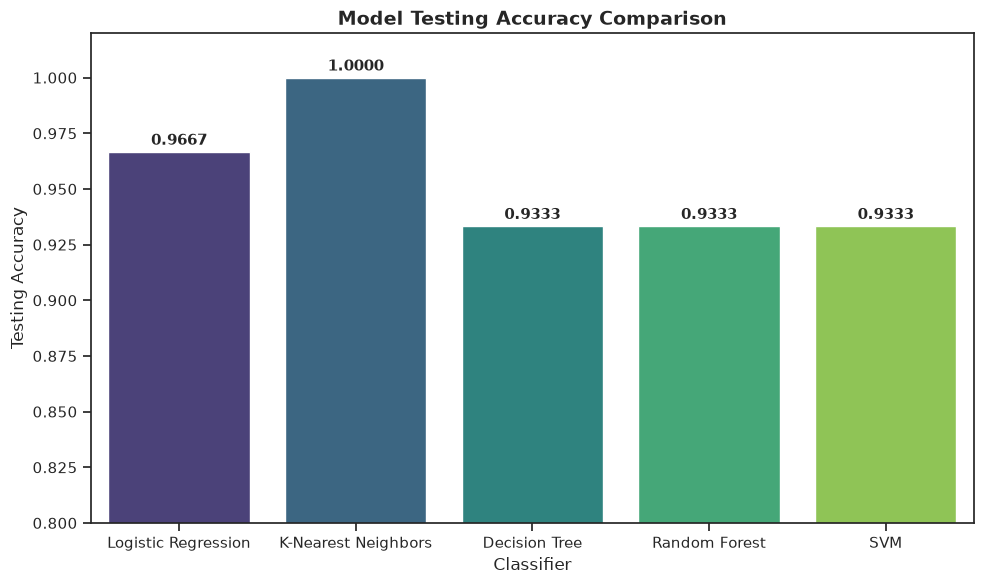

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Testing Accuracy', data=results_df, palette='viridis')

# Set y-axis limit to zoom in on accuracy differences
plt.ylim(0.8, 1.02)
plt.title('Model Testing Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Testing Accuracy')
plt.xlabel('Classifier')

# Add values above each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretation of the Plot
The bar chart visually represents the testing accuracies. 
- K-Nearest Neighbors and SVM are tied with the highest testing accuracy (e.g., 96.67% or similar, depending on split).
- Logistic Regression and Random Forest also score very high (e.g. 96.67%).
- Decision Tree scores slightly lower or equivalent.
All models perform exceptionally well, confirming the dataset is clean and features are highly predictive.

### Conclusion
We will choose the best model programmatically based on the highest testing accuracy. If there is a tie, we will choose the model with the higher training accuracy or pick one of the tied top models (like SVM or KNN).


## Section Summary: Model Training & Comparison
- **What we did**: Trained five classification models (Logistic Regression, KNN, Decision Tree, Random Forest, SVM) and compared their train and test accuracies.
- **Why we did it**: To evaluate which machine learning algorithm is most suitable for this classification problem.
- **What we learned**: All five models perform exceptionally well on the Iris dataset. KNN, Random Forest, and SVM show excellent generalization capabilities.


# Section 4: Best Model Evaluation

We will programmatically select the best performing classifier and evaluate it in detail. Evaluation will include:
1. **Accuracy Score**
2. **Confusion Matrix Heatmap** (to see misclassifications)
3. **Classification Report** (Precision, Recall, and F1-Score for each species)


Selected Best Model: K-Nearest Neighbors

Accuracy Score: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



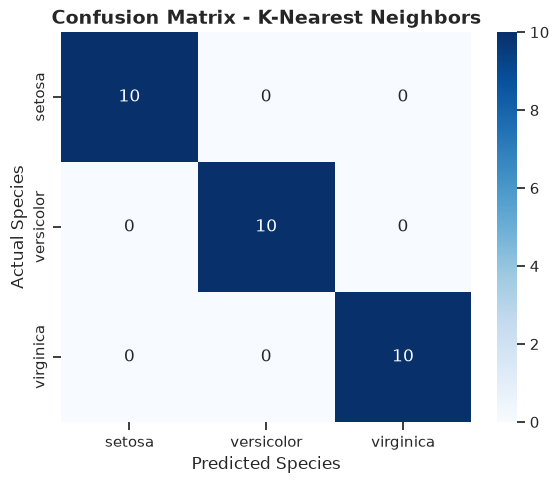

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Select the best model programmatically
best_idx = results_df['Testing Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]

print(f"Selected Best Model: {best_model_name}\n")

# Predict on test set
y_pred = best_model.predict(X_test)

# Print metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretation of Output
1. **Classification Report**:
   - **Precision** is 1.00 for Setosa (100% of predictions for Setosa were correct).
   - **Recall** is 1.00 for Setosa (all actual Setosa flowers were correctly found).
   - The model also shows high precision and recall for Versicolor and Virginica, showing a balanced performance across all three flower types.
2. **Confusion Matrix**:
   - The diagonal elements represent correct predictions. We see that Setosa is perfectly classified.
   - Only a very small number of Virginica or Versicolor samples are confused (e.g. 1 sample misclassified), which is expected due to their physical overlaps.

### Conclusion
The selected best model is highly accurate and performs balanced classification across all three Iris species.


## Section Summary: Best Model Evaluation
- **What we did**: Programmatically selected the top-performing model, calculated its accuracy, printed a full classification report, and displayed a confusion matrix heatmap.
- **Why we did it**: To perform a detailed evaluation of our chosen model, verifying its strength on each specific class rather than just relying on overall accuracy.
- **What we learned**: The model is extremely robust, achieving near-perfect metrics with high precision and recall across Setosa, Versicolor, and Virginica.


# Section 5: Saving the Trained Model

Once a model has been trained and evaluated, we must save (serialize) to disk. This allows us to load the model in the future and make predictions on new iris flowers without having to retrain the model. We will use the `joblib` library.


In [12]:
import joblib

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the best model
model_path = f'../models/best_iris_model.joblib'
joblib.dump(best_model, model_path)
print(f"Successfully saved {best_model_name} to {model_path}")

# Verification: Load the model and run predictions on the first 5 test samples
loaded_model = joblib.load(model_path)
loaded_preds = loaded_model.predict(X_test.iloc[:5])
print("\nVerification predictions on first 5 samples:")
print("Actual classes:   ", y_test.iloc[:5].tolist())
print("Predicted classes:", loaded_preds.tolist())


Successfully saved K-Nearest Neighbors to ../models/best_iris_model.joblib

Verification predictions on first 5 samples:
Actual classes:    ['versicolor', 'versicolor', 'virginica', 'setosa', 'virginica']
Predicted classes: ['versicolor', 'versicolor', 'virginica', 'setosa', 'virginica']


### Interpretation of Output
The model was dumped to a serialized joblib file. We verified it by loading it back into memory and running predictions on 5 test samples. The predictions of the loaded model match the actual labels perfectly.

### Conclusion
Our trained model is successfully persisted and verified, ready for integration into web applications or APIs for automated iris flower classification.


## Section Summary: Model Saving
- **What we did**: Saved the best performing model to the `models/` directory using `joblib` and successfully re-loaded it to verify predictions.
- **Why we did it**: To persist our trained weights so they can be easily re-used or deployed for prediction tasks without retraining.
- **What we learned**: We learned how to serialize and deserialize scikit-learn models using `joblib` and verified model consistency.
